In [1]:
import pandas as pd
df = pd.read_excel("Dataset_Mundial.xlsx", engine="openpyxl")
df.head()

,IDENTIFICACIÓN,Unnamed: 1,Unnamed: 2,UBICACIÓN,Unnamed: 4,Unnamed: 5,Unnamed: 6,TERRENO,Unnamed: 8,Unnamed: 9,...,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,TÉCNICO,Unnamed: 27,Unnamed: 28
0,OBJECTID,CÓDIGO,NOMBRE,PAÍS,ESTADO,LONGITUD,LATITUD,ELEVACIÓN,ÁREA,TAMAÑO,...,IRRADIANCIA GLOBAL,HUMEDAD,VELOCIDAD DEL VIENTO,DIRECCIÓN DEL VIENTO,DT_VIENTO,APTITUD SOLAR,T_APTITUDS,CAPACIDAD,INCLINACIÓN ÓPTIMA,POTENCIAL FOTOVOLTÁICO
1,NaN,NaN,NaN,NaN,NaN,Grados (°),Grados (°),msnm,m^2,NaN,...,kWh/m^2,Porcentaje (%),m/s,Grados (°),NaN,NaN,NaN,MW,Grados (°),kWh/kWp
2,2,00001-AFG-P,Badghis Solar Power Plant,Afghanistan,cancelled - inferred 4 y,62.8735,35.0779,918,6.735027,Pequeña,...,5.82425,47.742683,0.038896,187.48082,South,0.719865,Alta,32,30,4.61252
3,3,00002-AFG-P,Balkh solar farm,Afghanistan,cancelled - inferred 4 y,67.121,36.7144,359,10.718125,Pequeña,...,5.57908,42.304672,0.953698,207.421524,Southwest,0.634962,Alta,40,31,4.40769
4,4,00003-AFG-P,Behsood solar farm,Afghanistan,cancelled - inferred 4 y,70.4127,34.4067,629,487.729162,Pequeña,...,5.80463,36.395756,0.233703,255.60054,West,0.684814,Alta,60,31.062901,4.57171


In [2]:
import pandas as pd

path = "Dataset_Mundial.xlsx"

# Lee tomando como encabezado la fila donde están OBJECTID, CÓDIGO, NOMBRE, etc.
df = pd.read_excel(path, header=1)   # si esa fila es la 2da del excel

# Borra la fila de unidades si quedó como primera fila de datos
df = df[~df.apply(lambda r: r.astype(str).str.contains("Grados|msnm|m\\^2", case=False, regex=True).any(), axis=1)]

df = df.reset_index(drop=True)
df.head()

,OBJECTID,CÓDIGO,NOMBRE,PAÍS,ESTADO,LONGITUD,LATITUD,ELEVACIÓN,ÁREA,TAMAÑO,...,IRRADIANCIA GLOBAL,HUMEDAD,VELOCIDAD DEL VIENTO,DIRECCIÓN DEL VIENTO,DT_VIENTO,APTITUD SOLAR,T_APTITUDS,CAPACIDAD,INCLINACIÓN ÓPTIMA,POTENCIAL FOTOVOLTÁICO
0,2.0,00001-AFG-P,Badghis Solar Power Plant,Afghanistan,cancelled - inferred 4 y,62.8735,35.0779,918,6.735027,Pequeña,...,5.82425,47.742683,0.038896,187.48082,South,0.719865,Alta,32,30,4.61252
1,3.0,00002-AFG-P,Balkh solar farm,Afghanistan,cancelled - inferred 4 y,67.121,36.7144,359,10.718125,Pequeña,...,5.57908,42.304672,0.953698,207.421524,Southwest,0.634962,Alta,40,31,4.40769
2,4.0,00003-AFG-P,Behsood solar farm,Afghanistan,cancelled - inferred 4 y,70.4127,34.4067,629,487.729162,Pequeña,...,5.80463,36.395756,0.233703,255.60054,West,0.684814,Alta,60,31.062901,4.57171
3,5.0,00004-AFG-P,Dab Pal 4 solar farm,Afghanistan,shelved - inferred 2 y,66.2385,33.768,2288,111.80128,Pequeña,...,6.74873,37.343876,0.943275,160.330536,South,0.659418,Alta,3000,33,5.42396
4,6.0,00005-AFG-P,Daman solar farm,Afghanistan,cancelled - inferred 4 y,65.7139,31.6536,1060,1929.963835,Pequeña,...,6.62374,24.226305,0.370296,97.714561,East,0.819207,Alta,100,31,5.17134


In [3]:
df.shape[0]

59020

# ✅ **EDA**


In [4]:
import pandas as pd
import numpy as np

num_cols = [
    "LONGITUD","LATITUD","ELEVACIÓN","ÁREA","PENDIENTE",
    "DISTANCIA A LA VIA","TEMPERATURA","IRRADIANCIA GLOBAL",
    "HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "CAPACIDAD","INCLINACIÓN ÓPTIMA","POTENCIAL FOTOVOLTÁICO"
]

def to_float(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace("\u00a0", "", regex=False)  # espacios raros
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(",", ".", regex=False)      # coma decimal -> punto
    # deja solo dígitos, signo, punto (quita texto extra)
    s = s.str.replace(r"[^0-9\.\-]+", "", regex=True)
    return pd.to_numeric(s, errors="coerce")

for c in num_cols:
    if c in df.columns:
        df[c] = to_float(df[c])

df[num_cols].dtypes

,0
LONGITUD,float64
LATITUD,float64
ELEVACIÓN,int64
ÁREA,float64
PENDIENTE,float64
DISTANCIA A LA VIA,float64
TEMPERATURA,float64
IRRADIANCIA GLOBAL,float64
HUMEDAD,float64
VELOCIDAD DEL VIENTO,float64


In [5]:
print(df.shape) # númeto filas y columnas
print(df.dtypes) #Tipos de variables

(59020, 29)
OBJECTID                  float64
CÓDIGO                     object
NOMBRE                     object
PAÍS                       object
ESTADO                     object
LONGITUD                  float64
LATITUD                   float64
ELEVACIÓN                   int64
ÁREA                      float64
TAMAÑO                     object
INICIAL                    object
PENDIENTE                 float64
T_PENDIENTE                object
CURVATURA                 float64
T_CURVATURA                object
ASPECTO                    object
T_ASPECTO                  object
DISTANCIA A LA VIA        float64
TEMPERATURA               float64
IRRADIANCIA GLOBAL        float64
HUMEDAD                   float64
VELOCIDAD DEL VIENTO      float64
DIRECCIÓN DEL VIENTO      float64
DT_VIENTO                  object
APTITUD SOLAR             float64
T_APTITUDS                 object
CAPACIDAD                 float64
INCLINACIÓN ÓPTIMA        float64
POTENCIAL FOTOVOLTÁICO    float64
dt

In [6]:
df.isnull().sum() #nulos

,0
OBJECTID,0
CÓDIGO,0
NOMBRE,0
PAÍS,0
ESTADO,0
LONGITUD,0
LATITUD,0
ELEVACIÓN,0
ÁREA,1727
TAMAÑO,0


In [7]:
df = df.dropna() #elimino filas con nulos

In [8]:
df.isnull().sum() #nulos

,0
OBJECTID,0
CÓDIGO,0
NOMBRE,0
PAÍS,0
ESTADO,0
LONGITUD,0
LATITUD,0
ELEVACIÓN,0
ÁREA,0
TAMAÑO,0


In [9]:
df.shape[0]

57286

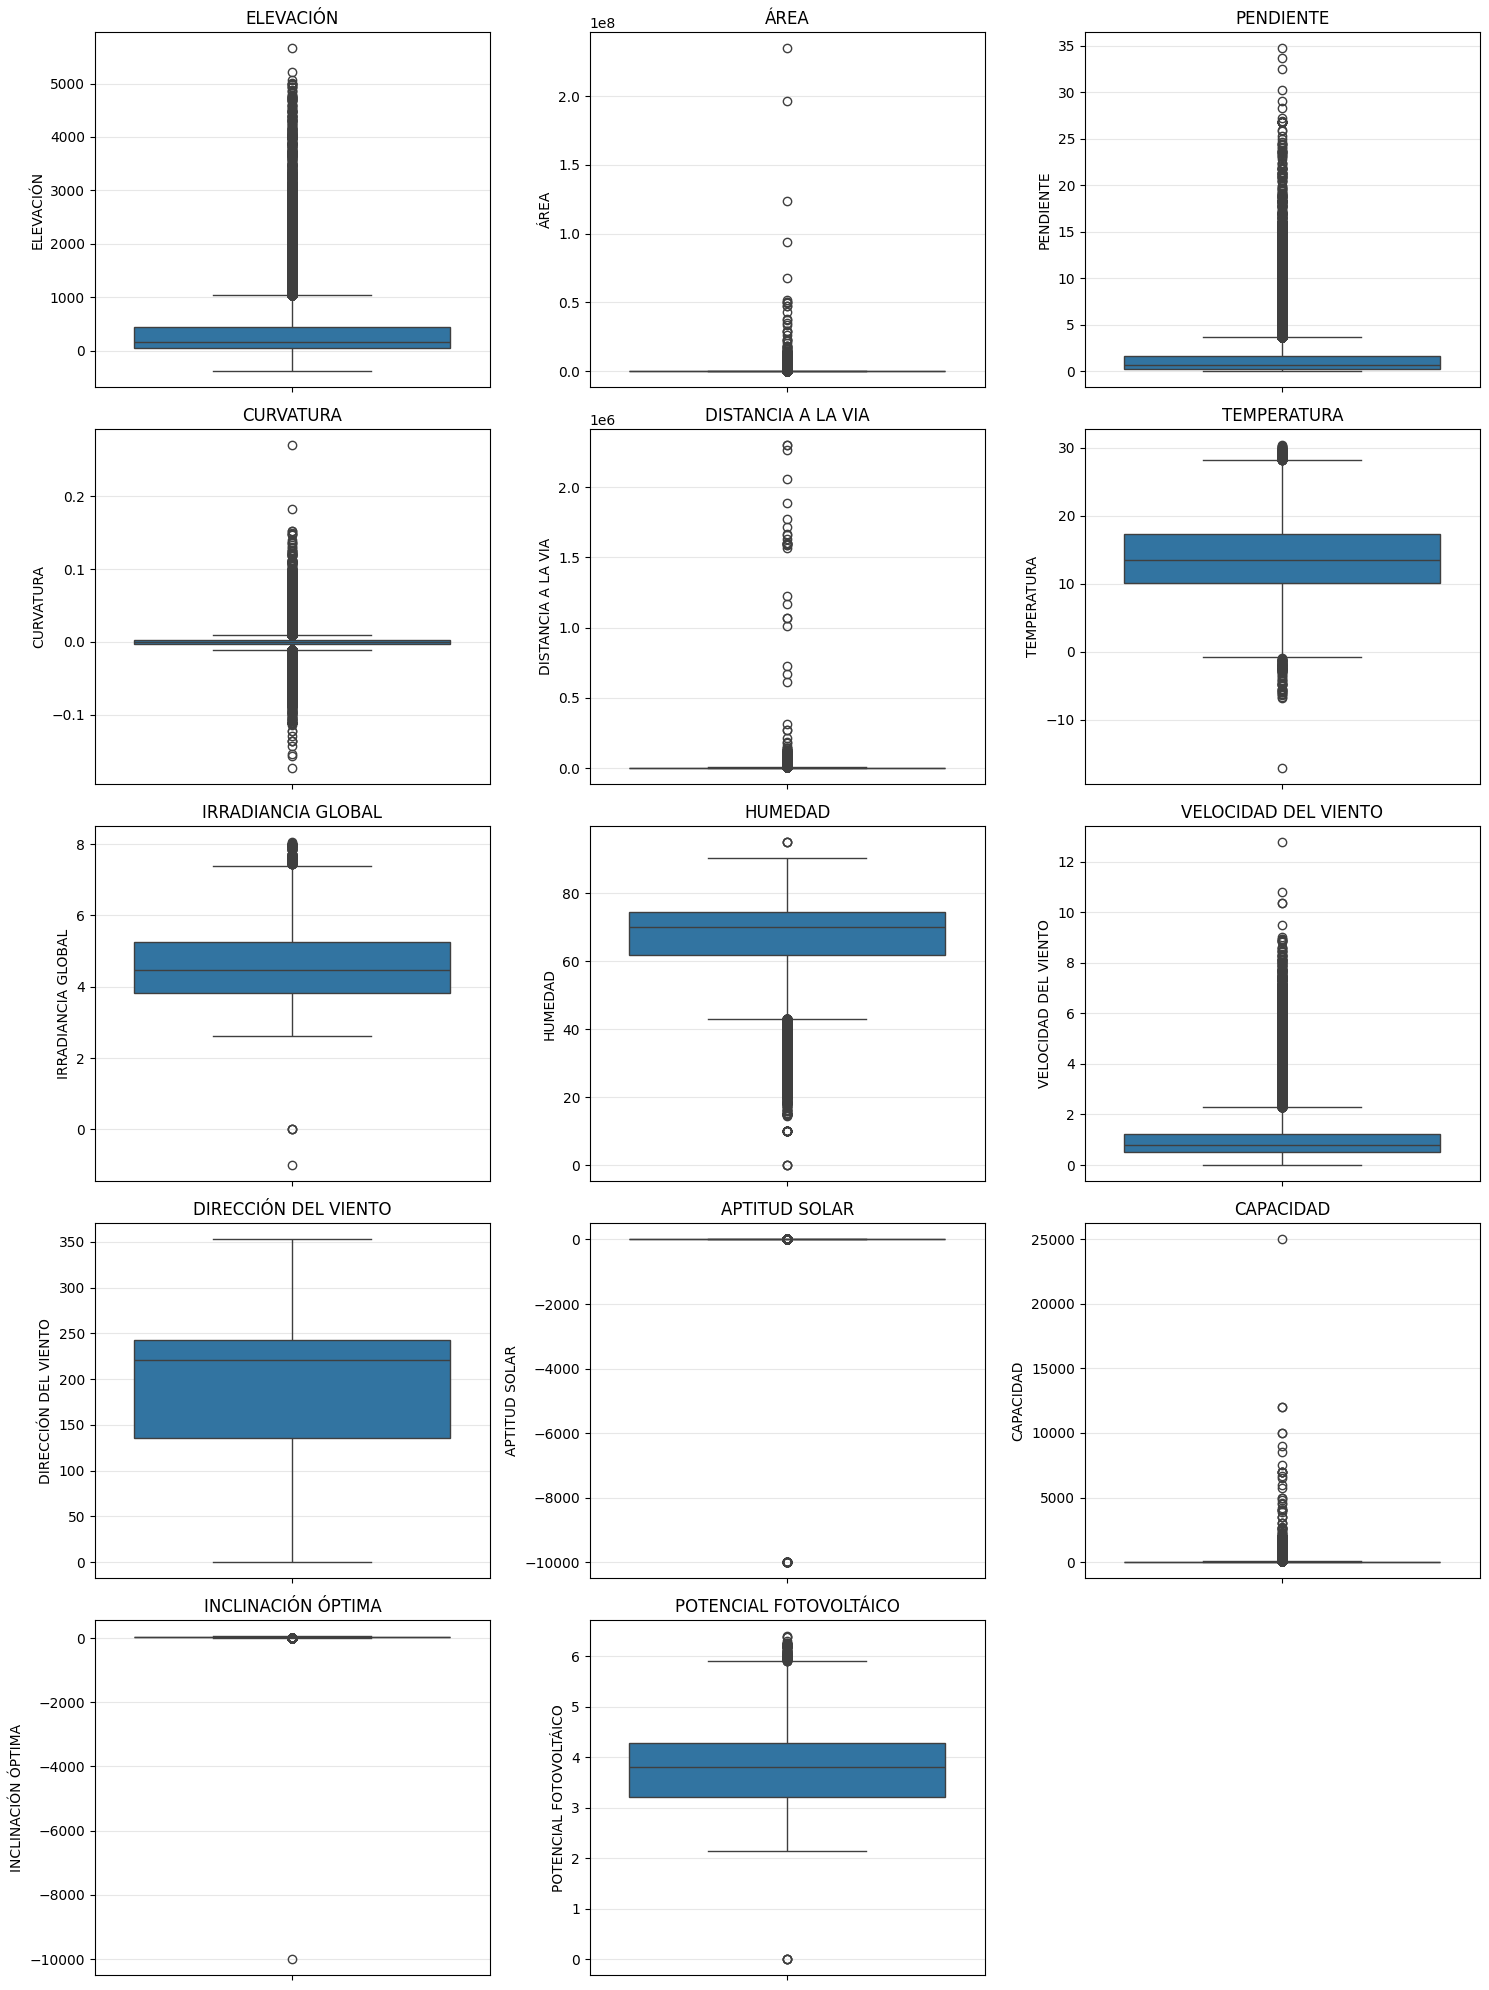

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas numéricas (int/float)
num_cols = [
    "ELEVACIÓN","ÁREA","PENDIENTE","CURVATURA","DISTANCIA A LA VIA","TEMPERATURA",
    "IRRADIANCIA GLOBAL","HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR","CAPACIDAD","INCLINACIÓN ÓPTIMA","POTENCIAL FOTOVOLTÁICO"
]

# Tamaño de grilla automático
n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)  # por si nrows=1

# Boxplots
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
df.loc[df["INCLINACIÓN ÓPTIMA"] < 0, ["OBJECTID","CÓDIGO","APTITUD SOLAR","INCLINACIÓN ÓPTIMA"]].head(20)
df.loc[df["APTITUD SOLAR"] < 0, ["OBJECTID","CÓDIGO","APTITUD SOLAR","INCLINACIÓN ÓPTIMA"]].head(20)

,OBJECTID,CÓDIGO,APTITUD SOLAR,INCLINACIÓN ÓPTIMA
407,25284.0,00408-AUS-M,-9999.0,27.0
895,975.0,00896-BRA-P,-9999.0,7.0
939,1365.0,00940-BRA-P,-9999.0,8.0
986,1638.0,00987-BRA-M,-9999.0,6.0
989,1644.0,00990-BRA-P,-9999.0,6.0
1008,1765.0,01009-BRA-P,-9999.0,7.0
1012,1782.0,01013-BRA-P,-9999.0,8.0
1088,2222.0,01089-BRA-P,-9999.0,7.0
1137,2658.0,01138-BRA-P,-9999.0,7.0
1163,2832.0,01164-BRA-M,-9999.0,7.0


In [12]:
cols = ["APTITUD SOLAR", "INCLINACIÓN ÓPTIMA"]

n_antes = len(df)
df = df[~(df[cols] < -10).any(axis=1)].copy()
n_despues = len(df)

print("antes:", n_antes, "después:", n_despues, "eliminadas:", n_antes - n_despues)

antes: 57286 después: 57249 eliminadas: 37


In [13]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ELEVACIÓN,57249.0,360.522210,5.323456e+02,-378.000000,48.000000,161.000000,444.000000,5.656000e+03
ÁREA,57249.0,134633.999777,1.727973e+06,0.000000,0.000000,2451.875000,35595.413946,2.347000e+08
PENDIENTE,57249.0,1.410624,2.223928e+00,0.000000,0.234689,0.654366,1.594470,3.468240e+01
CURVATURA,57249.0,-0.000475,1.378078e-02,-0.173207,-0.002942,-0.000191,0.002052,2.699230e-01
DISTANCIA A LA VIA,57249.0,3924.737444,3.469685e+04,0.000000,225.318543,751.247008,2782.395241,2.295655e+06
TEMPERATURA,57249.0,14.550565,5.847968e+00,-17.063900,10.125000,13.516300,17.375000,3.034060e+01
IRRADIANCIA GLOBAL,57249.0,4.554049,8.707400e-01,0.000000,3.829000,4.479600,5.265560,8.048000e+00
HUMEDAD,57249.0,66.695247,1.175493e+01,0.000000,61.989029,69.990000,74.577164,9.500000e+01
VELOCIDAD DEL VIENTO,57249.0,1.004487,9.443871e-01,0.000000,0.507232,0.787984,1.218804,1.275480e+01
DIRECCIÓN DEL VIENTO,57249.0,194.331123,5.912964e+01,0.000000,135.248932,221.267609,242.440002,3.525000e+02


In [14]:
cat_cols = ["PAÍS","TAMAÑO","T_PENDIENTE","T_CURVATURA","T_ASPECTO","DT_VIENTO","T_APTITUDS"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- PAÍS ---
PAÍS
China                    11518
United States             7224
Germany                   7108
Japan                     6871
India                     2907
                         ...  
North Korea                  1
Saint Kitts and Nevis        1
Timor-Leste                  1
Vanuatu                      1
Venezuela                    1
Name: count, Length: 183, dtype: int64

--- TAMAÑO ---
TAMAÑO
Pequeña    39340
Mediana    13208
Grande      4701
Name: count, dtype: int64

--- T_PENDIENTE ---
T_PENDIENTE
Plano o casi plano     45875
Suave                   8005
Moderado                2634
Fuerte                   524
Muy fuerte               207
Escarpado o abrupto        4
Name: count, dtype: int64

--- T_CURVATURA ---
T_CURVATURA
Superficies planas o intermedias    46849
Superficies cóncavas / Valles        5813
Superficies convexas / Crestas       4587
Name: count, dtype: int64

--- T_ASPECTO ---
T_ASPECTO
South        8175
East         8044
Southeast    7838


In [15]:
import pandas as pd

# Features y target
X_cols = [
    "ELEVACIÓN","ÁREA","PENDIENTE","CURVATURA","DISTANCIA A LA VIA","TEMPERATURA",
    "IRRADIANCIA GLOBAL","HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR","CAPACIDAD","INCLINACIÓN ÓPTIMA"
]
y_col = "POTENCIAL FOTOVOLTÁICO"

# Dataset final para modelar
df_model = df[X_cols + [y_col]].copy()

print(df_model.columns)  # columnas con las que se van a trabajar


Index(['ELEVACIÓN', 'ÁREA', 'PENDIENTE', 'CURVATURA', 'DISTANCIA A LA VIA',
       'TEMPERATURA', 'IRRADIANCIA GLOBAL', 'HUMEDAD', 'VELOCIDAD DEL VIENTO',
       'DIRECCIÓN DEL VIENTO', 'APTITUD SOLAR', 'CAPACIDAD',
       'INCLINACIÓN ÓPTIMA', 'POTENCIAL FOTOVOLTÁICO'],
      dtype='object')


# ✅ **Visualización con TSNE**


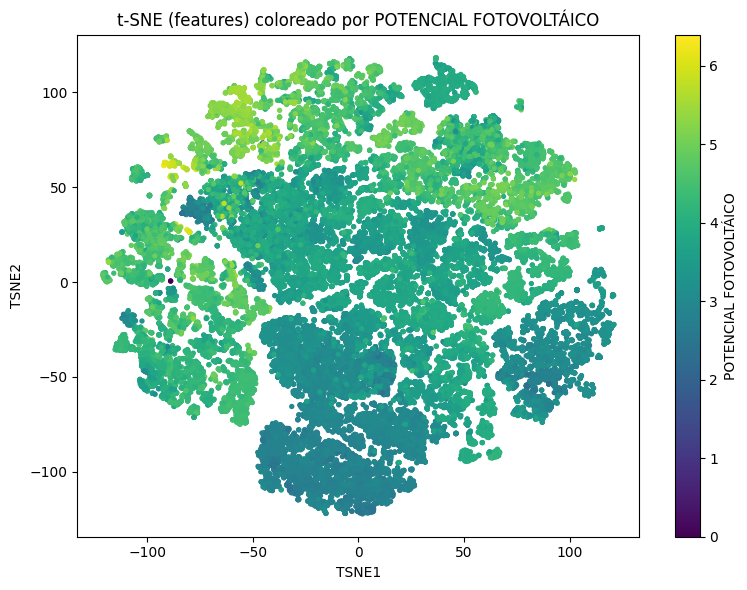

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_cols = [
    "ELEVACIÓN","ÁREA","PENDIENTE","CURVATURA","DISTANCIA A LA VIA","TEMPERATURA",
    "IRRADIANCIA GLOBAL","HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR","CAPACIDAD","INCLINACIÓN ÓPTIMA"
]
y_col = "POTENCIAL FOTOVOLTÁICO"

df_tsne = df[X_cols + [y_col]].dropna().copy()

X = df_tsne[X_cols].values
y = df_tsne[y_col].values

# Escalar SOLO para t-SNE
X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)

X_emb = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "TSNE1": X_emb[:, 0],
    "TSNE2": X_emb[:, 1],
    y_col: y
})

# Plot: color continuo
plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], c=tsne_df[y_col], s=8)
plt.colorbar(sc, label=y_col)
plt.title("t-SNE (features) coloreado por POTENCIAL FOTOVOLTÁICO")
plt.xlabel("TSNE1"); plt.ylabel("TSNE2")
plt.tight_layout()
plt.show()

# ✅ **CREAR GRUPOS (grid espacial)**


In [17]:
import numpy as np
import pandas as pd

X_cols = [
    "ELEVACIÓN","ÁREA","PENDIENTE","CURVATURA","DISTANCIA A LA VIA","TEMPERATURA",
    "IRRADIANCIA GLOBAL","HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR","CAPACIDAD","INCLINACIÓN ÓPTIMA"
]
target = "POTENCIAL FOTOVOLTÁICO"

# dataset base (incluye coords para crear grupos)
df_model = df[X_cols + [target, "LATITUD", "LONGITUD"]].dropna().copy()

# tamaño del bloque (km)
cell_km = 50.0
deg_lat = cell_km / 111.0 #1 grado de latitud equivale aproximadamente a 111 km en la Tierra

lat = df_model["LATITUD"].to_numpy()
lon = df_model["LONGITUD"].to_numpy()

deg_lon = cell_km / (111.0 * np.cos(np.deg2rad(lat)).clip(0.2, None))# 1° de longitud vale aprox. 111·cos(lat) km, para convertir km→grados de longitud

lat_bin = np.floor((lat - lat.min()) / deg_lat).astype(int)# calcula en qué “bloque” de tamaño deg_lat cae la latitud
lon_bin = np.floor((lon - lon.min()) / deg_lon).astype(int)

groups = (lat_bin.astype(str) + "_" + lon_bin.astype(str))  # group id por celda
groups_s = pd.Series(groups, index=df_model.index, name="grid_id")

# guardar el id en el df para inspección
df_model["grid_id"] = groups_s.values

# ✅ **SPLIT EN TRAIN / VAL / TEST (por grupos)**

In [18]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

X = df_model[X_cols]
y = df_model[target]
groups = df_model["grid_id"].values  # aseguramos array

# train (70%) vs temp (30%)
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)#asegura que los grupos (grid_id) no se mezclen entre train y el resto
train_idx, temp_idx = next(gss.split(X, y, groups=groups))#devuelve los índices de las filas que van a train (train_idx) y las que van al conjunto temporal

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx] #Toma esas filas por índice y arma los datasets: train (X_train, y_train) y el temporal (X_temp, y_temp).
X_temp,  y_temp  = X.iloc[temp_idx],  y.iloc[temp_idx] #g_temp guarda los IDs de grupo (grid_id) correspondientes a X_temp, para poder volver a hacer otro split por grupos
g_temp = groups[temp_idx]

# temp -> val (15%) y test (15%)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_rel_idx, test_rel_idx = next(gss2.split(X_temp, y_temp, groups=g_temp))

X_val,  y_val  = X_temp.iloc[val_rel_idx],  y_temp.iloc[val_rel_idx]
X_test, y_test = X_temp.iloc[test_rel_idx], y_temp.iloc[test_rel_idx]

# guardar índices para reproducibilidad exacta
idx_train = X_train.index
idx_val   = X_val.index
idx_test  = X_test.index

In [19]:
import numpy as np
import pandas as pd

print("=== Columnas usadas (X) ===")
print(X_cols)
print("\n=== Target (y) ===")
print(target)

print("\n=== Tamaños de splits (filas) ===")
print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

# info de grupos (global)
vc = df_model["grid_id"].value_counts()
print("\n=== Grupos (celdas) ===")
print("Total grupos:", df_model["grid_id"].nunique())

print("\nTop 10 celdas con más puntos:")
print(vc.head(10))

# grupos por split y chequeo de fuga
train_groups = set(df_model.loc[idx_train, "grid_id"])
val_groups   = set(df_model.loc[idx_val,   "grid_id"])
test_groups  = set(df_model.loc[idx_test,  "grid_id"])

print("\n=== Grupos por split ===")
print("Grupos en TRAIN:", len(train_groups))
print("Grupos en VAL:", len(val_groups))
print("Grupos en TEST:", len(test_groups))

print("\n=== Chequeo intersecciones (debe dar 0) ===")
print("train ∩ val :", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val ∩ test  :", len(val_groups & test_groups))

=== Columnas usadas (X) ===
['ELEVACIÓN', 'ÁREA', 'PENDIENTE', 'CURVATURA', 'DISTANCIA A LA VIA', 'TEMPERATURA', 'IRRADIANCIA GLOBAL', 'HUMEDAD', 'VELOCIDAD DEL VIENTO', 'DIRECCIÓN DEL VIENTO', 'APTITUD SOLAR', 'CAPACIDAD', 'INCLINACIÓN ÓPTIMA']

=== Target (y) ===
POTENCIAL FOTOVOLTÁICO

=== Tamaños de splits (filas) ===
train: (40750, 13) val: (7865, 13) test: (8634, 13)

=== Grupos (celdas) ===
Total grupos: 9233

Top 10 celdas con más puntos:
grid_id
172_473    192
172_474    188
173_471    183
169_471    183
173_470    170
200_199    169
171_476    167
172_472    166
169_474    152
173_469    151
Name: count, dtype: int64

=== Grupos por split ===
Grupos en TRAIN: 6463
Grupos en VAL: 1385
Grupos en TEST: 1385

=== Chequeo intersecciones (debe dar 0) ===
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


# ✅ **TabNet**


## Librerías

In [20]:
!pip -q install lightning torchmetrics pytorch-tabnet

In [21]:
!pip -q install pytorch-tabnet

In [22]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import lightning as L
import torchmetrics

from sklearn.preprocessing import StandardScaler
from pytorch_tabnet.tab_network import TabNet

from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

from pytorch_tabnet.tab_model import TabNetRegressor
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pandas as pd

## Preparación de X e y (scaling + NumPy)

In [23]:
X_cols = [
    "ELEVACIÓN","ÁREA","PENDIENTE","CURVATURA","DISTANCIA A LA VIA","TEMPERATURA",
    "IRRADIANCIA GLOBAL","HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR","CAPACIDAD","INCLINACIÓN ÓPTIMA"
]
target = "POTENCIAL FOTOVOLTÁICO"

#Estandariza las features con Z-score
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train).astype(np.float32)
X_val_np   = scaler.transform(X_val).astype(np.float32)
X_test_np  = scaler.transform(X_test).astype(np.float32)
#Convierte el target a NumPy
y_train_np = y_train.to_numpy().astype(np.float32).reshape(-1, 1)
y_val_np   = y_val.to_numpy().astype(np.float32).reshape(-1, 1)
y_test_np  = y_test.to_numpy().astype(np.float32).reshape(-1, 1)

## Definición y entrenamiento de TabNetRegressor

In [24]:
import torch

tabnet = TabNetRegressor(
    n_d=32, #tamaño del vector del bloque de DECISIÓN en cada paso: produce una representación interna de 32 valores
    n_a=32,  # tamaño del vector del bloque de ATENCIÓN: genera la información interna con la que TabNet calcula la máscara sobre las 13 variables (qué variables “mirar” más en ese paso).
    n_steps=5,  # Número de pasos secuenciales dentro del forward (por batch): TabNet repite 5 veces el ciclo “calcular máscara → seleccionar variables → producir representación”
    gamma=1.5, #controla la reutilización de variables entre pasos:influye en que cada paso explore variables nuevas o vuelva a usar las mismas.
    n_independent=2,  # bloques con pesos NO compartidos en cada paso
    n_shared=2,  # Cantidad de bloques con pesos compartidos entre todos los pasos
    lambda_sparse=1e-4,  # sparsidad en las máscaras: empuja a que en cada paso la máscara se concentre en pocas variables
    optimizer_fn=torch.optim.Adam,  #
    optimizer_params=dict(lr=2e-3, weight_decay=1e-5)
)

tabnet.fit(
    X_train_np, y_train_np,#Train
    eval_set=[(X_val_np, y_val_np)],#validación
    eval_name=["val"],
    eval_metric=["rmse"],# RMSE para regresión
    max_epochs=200,
    patience=20,#Early stopping
    batch_size=1024,#batch
    virtual_batch_size=256,# “Ghost batch”: batch virtual para BatchNorm, mejora estabilidad con batches grandes
    num_workers=0,
    drop_last=False # No descarta el último batch aunque sea más pequeño que batch_size
)

history = tabnet.history

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 6.27203 | val_rmse: 1.32956 |  0:00:02s
epoch 1  | loss: 0.95624 | val_rmse: 0.7266  |  0:00:05s
epoch 2  | loss: 0.47266 | val_rmse: 0.47653 |  0:00:07s
epoch 3  | loss: 0.30528 | val_rmse: 0.4897  |  0:00:09s
epoch 4  | loss: 0.21455 | val_rmse: 0.36971 |  0:00:12s
epoch 5  | loss: 0.1725  | val_rmse: 0.35203 |  0:00:14s
epoch 6  | loss: 0.13534 | val_rmse: 0.33221 |  0:00:15s
epoch 7  | loss: 0.12106 | val_rmse: 0.28792 |  0:00:16s
epoch 8  | loss: 0.09541 | val_rmse: 0.26628 |  0:00:18s
epoch 9  | loss: 0.08152 | val_rmse: 0.24879 |  0:00:21s
epoch 10 | loss: 0.07278 | val_rmse: 0.27936 |  0:00:23s
epoch 11 | loss: 0.06616 | val_rmse: 0.24238 |  0:00:25s
epoch 12 | loss: 0.06234 | val_rmse: 0.21201 |  0:00:28s
epoch 13 | loss: 0.06055 | val_rmse: 0.21368 |  0:00:30s
epoch 14 | loss: 0.05517 | val_rmse: 0.21264 |  0:00:32s
epoch 15 | loss: 0.04866 | val_rmse: 0.18806 |  0:00:35s
epoch 16 | loss: 0.04285 | val_rmse: 0.18396 |  0:00:37s
epoch 17 | loss: 0.04395 | val_

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## Curvas de aprendizaje: pérdida de entrenamiento y RMSE de validación

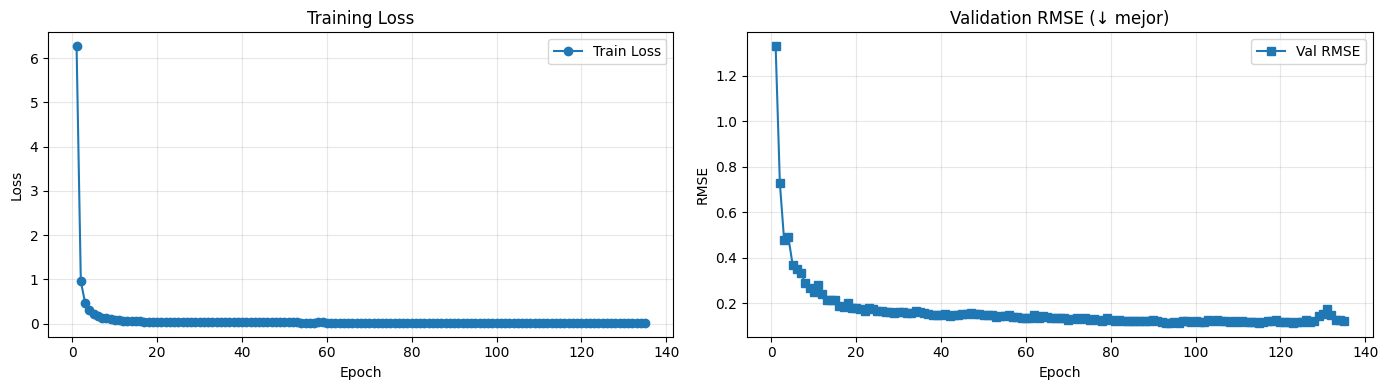

In [25]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = history["loss"]
val_rmse   = history["val_rmse"]  # eval_metric=["rmse"]
epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14,4))

# Train Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, marker="o", label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# Val RMSE (normal)
plt.subplot(1,2,2)
plt.plot(epochs, val_rmse, marker="s", label="Val RMSE")
plt.title("Validation RMSE (↓ mejor)")
plt.xlabel("Epoch"); plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
pred_test = tabnet.predict(X_test_np).reshape(-1)
y_true = y_test_np.reshape(-1)

mse  = mean_squared_error(y_true, pred_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, pred_test)
r2   = r2_score(y_true, pred_test)

print(f"TEST -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

TEST -> RMSE: 0.1221 | MAE: 0.0763 | R2: 0.9679


## Evaluación en test: gráfico Real vs Predicho

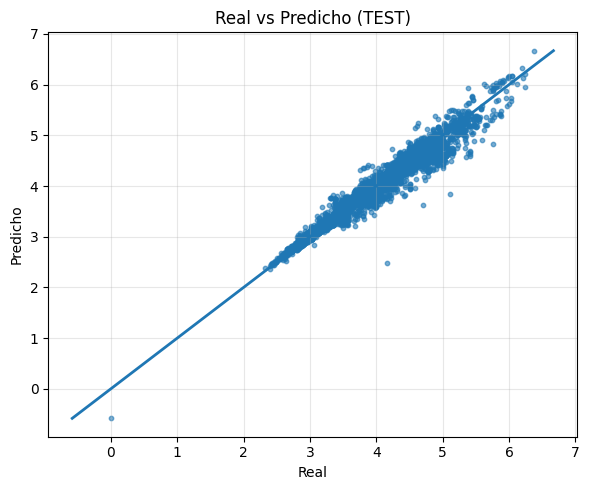

In [27]:
y_true = y_test_np.reshape(-1)
y_pred = tabnet.predict(X_test_np).reshape(-1)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())

plt.figure(figsize=(6,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
plt.plot([mn, mx], [mn, mx], linewidth=2)  # línea ideal
plt.title("Real vs Predicho (TEST)")
plt.xlabel("Real"); plt.ylabel("Predicho")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretabilidad: importancia de variables (TabNet)

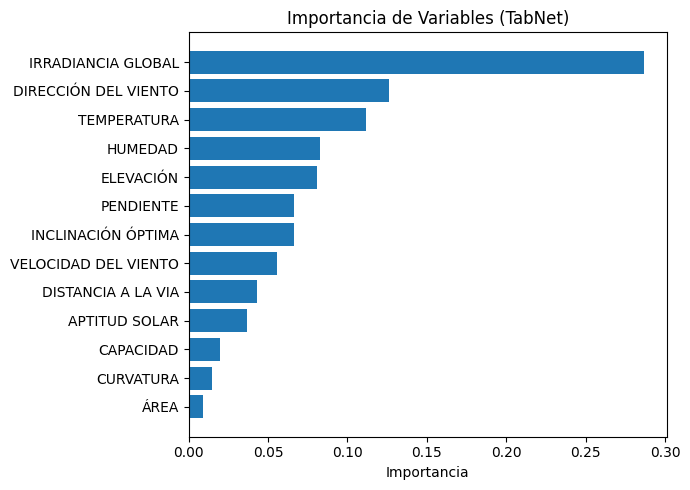

,0
IRRADIANCIA GLOBAL,0.286881
DIRECCIÓN DEL VIENTO,0.126479
TEMPERATURA,0.111904
HUMEDAD,0.082858
ELEVACIÓN,0.080751
PENDIENTE,0.066206
INCLINACIÓN ÓPTIMA,0.066148
VELOCIDAD DEL VIENTO,0.055394
DISTANCIA A LA VIA,0.043233
APTITUD SOLAR,0.036893


In [28]:
fi = tabnet.feature_importances_
imp = pd.Series(fi, index=X_cols).sort_values(ascending=False)

plt.figure(figsize=(7,5))
plt.barh(imp.index[::-1], imp.values[::-1])
plt.title("Importancia de Variables (TabNet)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

imp.head(10)

# ✅ TabPFN

In [29]:
!pip -q install tabpfn

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [31]:
from tabpfn import TabPFNRegressor
print("OK TabPFNRegressor")

OK TabPFNRegressor


In [32]:
!pip -q install -U "huggingface-hub==0.30.2" "hf-transfer" "transformers==4.51.3"

In [33]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `huggingface-cli whoami` to get more information or `huggingface-cli logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: read)

In [34]:
# Features y target (mismo set que TabNet)
X_cols = [
    "ELEVACIÓN","ÁREA","PENDIENTE","CURVATURA","DISTANCIA A LA VIA","TEMPERATURA",
    "IRRADIANCIA GLOBAL","HUMEDAD","VELOCIDAD DEL VIENTO","DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR","CAPACIDAD","INCLINACIÓN ÓPTIMA"
]
target = "POTENCIAL FOTOVOLTÁICO"

# Pasar a numpy
X_train_np = X_train[X_cols].to_numpy().astype(np.float32)
X_val_np   = X_val[X_cols].to_numpy().astype(np.float32)
X_test_np  = X_test[X_cols].to_numpy().astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32).reshape(-1)
y_val_np   = y_val.to_numpy().astype(np.float32).reshape(-1)
y_test_np  = y_test.to_numpy().astype(np.float32).reshape(-1)

In [35]:
best = None
best_rmse = float("inf")

for n_est in [8, 16, 32]: # distintos valores de n_estimators (tamaño del ensamble interno de TabPFN)
    for temp in [0.8, 0.9, 1.0]: #Probamos distintos valores de softmax_temperature (controla qué tan “suave” es el weighting interno)
        # Modelo TabPFN con combinación de hiperparámetros
        m = TabPFNRegressor(device="cuda", n_estimators=n_est, softmax_temperature=temp, random_state=42)
        m.fit(X_train_np, y_train_np.reshape(-1)) # Entrenamiento. y_train_np.reshape(-1) convierte y a vector 1D, formato que espera TabPFN
        pred_val = m.predict(X_val_np).reshape(-1)  # Predecimos en el conjunto de validación
        rmse = np.sqrt(mean_squared_error(y_val_np.reshape(-1), pred_val)) # Calculamos RMSE en validación

        if rmse < best_rmse:
            best_rmse = rmse
            best = (n_est, temp)

print("Mejor según VAL:", best, "RMSE:", best_rmse)  # mejor combinación y su RMSE en validación

Mejor según VAL: (8, 1.0) RMSE: 0.0338027606606278


In [36]:
#entrenar modelo final con los mejores hiperparámetros
best_n_est, best_temp = best

tabpfn_best = TabPFNRegressor(
    device="cuda",
    n_estimators=best_n_est,
    softmax_temperature=best_temp,
    random_state=42
)
tabpfn_best.fit(X_train_np, y_train_np.reshape(-1))


TabPFNRegressor(device='cuda', random_state=42, softmax_temperature=1.0)

In [37]:
#metricas
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

ytr = y_train_np.reshape(-1)
yva = y_val_np.reshape(-1)
yte = y_test_np.reshape(-1)

# predicciones
pred_train = tabpfn_best.predict(X_train_np).reshape(-1)
pred_val   = tabpfn_best.predict(X_val_np).reshape(-1)
pred_test  = tabpfn_best.predict(X_test_np).reshape(-1)

rmse_tr, mae_tr, r2_tr = metrics(ytr, pred_train)
rmse_va, mae_va, r2_va = metrics(yva, pred_val)
rmse_te, mae_te, r2_te = metrics(yte, pred_test)

print(f"Best params: n_estimators={best_n_est}, temp={best_temp}\n")

print(f"TRAIN -> RMSE={rmse_tr:.4f} | MAE={mae_tr:.4f} | R2={r2_tr:.4f}")
print(f"VAL   -> RMSE={rmse_va:.4f} | MAE={mae_va:.4f} | R2={r2_va:.4f}")
print(f"TEST  -> RMSE={rmse_te:.4f} | MAE={mae_te:.4f} | R2={r2_te:.4f}")

Best params: n_estimators=8, temp=1.0

TRAIN -> RMSE=0.0055 | MAE=0.0030 | R2=0.9999
VAL   -> RMSE=0.0338 | MAE=0.0109 | R2=0.9970
TEST  -> RMSE=0.0334 | MAE=0.0121 | R2=0.9976


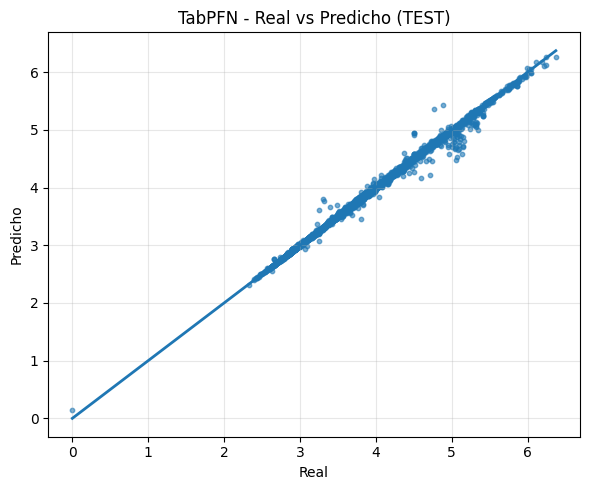

In [38]:
y_true = y_test_np
y_pred = pred_test

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())

plt.figure(figsize=(6,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.6)
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.title("TabPFN - Real vs Predicho (TEST)")
plt.xlabel("Real"); plt.ylabel("Predicho")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ✅ SAINT

# ✅ **SAINT supervisado**

## Imports y semilla

In [39]:
import math
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [40]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## Definir columnas y preparar arrays

In [41]:
X_cols = [
    "ELEVACIÓN",
    "ÁREA",
    "PENDIENTE",
    "CURVATURA",
    "DISTANCIA A LA VIA",
    "TEMPERATURA",
    "IRRADIANCIA GLOBAL",
    "HUMEDAD",
    "VELOCIDAD DEL VIENTO",
    "DIRECCIÓN DEL VIENTO",
    "APTITUD SOLAR",
    "CAPACIDAD",
    "INCLINACIÓN ÓPTIMA"
]

target = "POTENCIAL FOTOVOLTÁICO"

In [42]:
# se seleccionan las columnas de entrada en X_cols y se crea una copia
X_train_df = X_train[X_cols].copy()
X_val_df   = X_val[X_cols].copy()
X_test_df  = X_test[X_cols].copy()

# se convierte a un arreglo de NumPy, luego a tipo float32 (compatible con PyTorch) y se aplana a un vector de una dimensión
y_train_np = y_train.to_numpy().astype(np.float32).reshape(-1)
y_val_np   = y_val.to_numpy().astype(np.float32).reshape(-1)
y_test_np  = y_test.to_numpy().astype(np.float32).reshape(-1)

## Escalado de features

In [43]:
#estandarización Z-score
scaler_X = StandardScaler()

X_train_np = scaler_X.fit_transform(X_train_df).astype(np.float32)
X_val_np   = scaler_X.transform(X_val_df).astype(np.float32)
X_test_np  = scaler_X.transform(X_test_df).astype(np.float32)

print("Shapes:")
print("X_train:", X_train_np.shape, "y_train:", y_train_np.shape)
print("X_val  :", X_val_np.shape,   "y_val  :", y_val_np.shape)
print("X_test :", X_test_np.shape,  "y_test :", y_test_np.shape)

Shapes:
X_train: (40750, 13) y_train: (40750,)
X_val  : (7865, 13) y_val  : (7865,)
X_test : (8634, 13) y_test : (8634,)


## Dataset y DataLoader

sirve para empaquetar los datos tabulares (X) y el objetivo (y) en el formato que PyTorch entiende.

In [44]:
class TabularRegressionDataset(Dataset): ## Define una clase Dataset de PyTorch para regresión tabular
    def __init__(self, X, y): #Constructor: recibe X (features) e y (target)
        self.X = torch.tensor(X, dtype=torch.float32) # Convierte X a tensor float32
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1) # Convierte y a tensor float32

    def __len__(self): # Devuelve cuántas filas (muestras) hay en el dataset
        return len(self.X)

    def __getitem__(self, idx):  # Devuelve una muestra individual por índice
        return self.X[idx], self.y[idx]

In [45]:
batch_size = 256 # Número de muestras (filas) que se procesan juntas en cada paso de entrenamiento (bath)

# Crea el dataset de entrenamiento, val y test (X,y) en formato PyTorch
train_dataset = TabularRegressionDataset(X_train_np, y_train_np)
val_dataset   = TabularRegressionDataset(X_val_np, y_val_np)
test_dataset  = TabularRegressionDataset(X_test_np, y_test_np)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # DataLoader de train: entrega batches y mezcla cada época
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Tokenizador continuo

Sirve para convertir variables numéricas (escalas) en tokens/embeddings que un Transformer pueda procesar. Cada feature se transforma a un vector de dimensión d_token por columna, usando parámetros aprendibles (weight y bias) distintos para cada feature. Así, cada columna queda como un “token” con representación rica y el modelo puede aplicar self-attention entre columnas.

In [46]:
class ContinuousFeatureTokenizer(nn.Module): # Módulo que convierte features numéricas en “tokens” (embeddings) por columna
    def __init__(self, n_features, d_token): # Constructor: recibe número de features y dimensión del token (embedding)
        super().__init__()
        self.n_features = n_features # Guarda cuántas columnas (features) tiene X
        self.d_token = d_token # Guarda el tamaño del vector embedding para cada columna

        self.weight = nn.Parameter(torch.empty(n_features, d_token)) # Parámetros aprendibles: pesos por feature para mapear escalar→vector
        self.bias = nn.Parameter(torch.empty(n_features, d_token)) # Parámetros aprendibles: sesgo por feature para mapear escalar→vector

        nn.init.xavier_uniform_(self.weight) # Inicializa los pesos con xavier para mantener las activaciones y gradientes “estables” al inicio, evitando que se disparen o se desvanezcan
        nn.init.zeros_(self.bias) # Inicializa los sesgos en cero

    def forward(self, x): # Define forward (cómo se transforma la entrada)
        x = x.unsqueeze(-1)  # cada feature queda tokenizable, escalar
        return x * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)  # Produce tokens

## Multi-Head Self-Attention

Ese bloque implementa self-attention multi-head: toma los embeddings de los tokens (columnas/features) y, para cada token, aprende a ponderar y mezclar información de todos los demás tokens, capturando interacciones complejas entre variables. Las “múltiples cabezas” permiten aprender distintos tipos de relaciones en paralelo (por ejemplo, una cabeza puede fijarse en variables climáticas y otra en geométricas).

In [47]:
class MultiHeadSelfAttention(nn.Module): ## Self-Attention multi-head (tipo Transformer)
    def __init__(self, d_model, n_heads, dropout=0.1): # d_model = dimensión del embedding, n_heads= cabezas
        super().__init__()
        assert d_model % n_heads == 0, "d_model debe ser divisible para n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads #Dimensión por cabeza

        self.q_proj = nn.Linear(d_model, d_model) # para obtener Q desde x
        self.k_proj = nn.Linear(d_model, d_model) # para obtener K desde x
        self.v_proj = nn.Linear(d_model, d_model) # para obtener V desde x
        self.out_proj = nn.Linear(d_model, d_model) #Proyección para mezclar cabezas

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, T, D]
        B, T, D = x.shape # B=batch (filas), T=tokens (columnas/features), D=d_model

        # Proyecta x a Q, K, V y lo reorganiza en multi-head:
        # view -> separa D en (H, dh); transpose -> pone H como dimensión “de cabeza”
        Q = self.q_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # Producto punto QK^T para obtener “scores” de atención entre tokens
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = torch.softmax(scores, dim=-1)  # Convierte scores en probabilidades
        attn = self.dropout(attn) # Aplica dropout a las probabilidades de atención

        # Recombina las cabezas
        out = attn @ V  # # Combina values según la atención
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out_proj(out) #Proyección final para producir salida en dimensión D

## transformer para atención entre columnas

Sirve para crear un bloque de Transformer Encoder:

- Self-attention para mezclar información entre tokens (columnas/features)

- Feed-forward network (MLP) para transformar cada token de forma no lineal
con residual connections + LayerNorm + dropout para estabilidad y regularización.

In [48]:
class TransformerBlock(nn.Module): # bloque Transformer (Encoder) reutilizable
    def __init__(self, d_model, n_heads, mlp_ratio=4, dropout=0.1): # d_model: dimensión del embedding, n_heads: cabezas de atención
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model) #Normalización antes de la atención (pre-norm) para estabilidad
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout) #Self-attention multi-cabeza (mezcla info entre tokens)
        self.dropout1 = nn.Dropout(dropout)  # Dropout aplicado a la salida de atención (regulariza)

        self.norm2 = nn.LayerNorm(d_model) #Segunda normalización antes del MLP (pre-norm)
        self.ffn = nn.Sequential(  # Feed-forward network (MLP) aplicada a cada token
            nn.Linear(d_model, d_model * mlp_ratio), # Expande dimensión
            nn.GELU(), # Activación no lineal GELU
            nn.Dropout(dropout), # Dropout dentro del MLP (regulariza)
            nn.Linear(d_model * mlp_ratio, d_model), # Proyección
        )
        self.dropout2 = nn.Dropout(dropout) # Dropout aplicado a la salida del MLP (regulariza)

    def forward(self, x):
        x = x + self.dropout1(self.attn(self.norm1(x))) # Residual 1: normaliza -> atención -> dropout -> suma con x
        x = x + self.dropout2(self.ffn(self.norm2(x))) # Residual 2: normaliza -> MLP -> dropout -> suma con x
        return x

## Atención entre filas del batch

Para cada token/feature, una muestra pueda “mirar” a otras muestras del mismo batch y mezclar información entre filas, lo que puede ayudar a aprender patrones


In [50]:
import torch
import torch.nn as nn

class IntersampleAttention(nn.Module):  # Atención “entre muestras” (entre filas del batch)
    def __init__(self, d_model, n_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()

        # ---- Parte 1: Intersample Attention (Add & Norm + Multi-Head Intersample Attention) ----
        self.norm1 = nn.LayerNorm(d_model)  # LayerNorm (pre-norm) antes de la atención para estabilizar el entrenamiento
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)  # Atención multi-cabeza (aquí la usaremos entre filas del batch)
        self.dropout1 = nn.Dropout(dropout)  # Dropout aplicado a la salida de la atención (regularización)

        # ---- Parte 2: FeedForward (Add & Norm + FFN) ----
        self.norm2 = nn.LayerNorm(d_model)  # Segunda LayerNorm (pre-norm) antes del MLP/FFN
        self.ffn = nn.Sequential(  # FeedForward Network típico de Transformer (aplica no linealidad y mezcla dimensiones)
            nn.Linear(d_model, d_model * mlp_ratio),  # Expande la dimensión: D -> D*mlp_ratio (más capacidad)
            nn.GELU(),  # Activación GELU (típica en Transformers)
            nn.Dropout(dropout),  # Dropout dentro del MLP para regularización
            nn.Linear(d_model * mlp_ratio, d_model),  # Proyección de vuelta: D*mlp_ratio -> D
        )
        self.dropout2 = nn.Dropout(dropout)  # Dropout aplicado a la salida del MLP/FFN

    def forward(self, x):
        # x: [B, T, D]  B=batch (filas), T=tokens (features/columnas), D=d_model (dimensión del embedding)

        # Queremos atender entre muestras del batch para cada token (o sea, mezclar filas entre sí)
        x_t = x.transpose(0, 1)  # [T, B, D] ahora B actúa como "seq_len": cada columna (token) ve todas las filas del batch

        # ---- (1) Intersample Attention + residual ----
        # cada fila del batch se mezcla con otras filas del batch (por cada columna), usando attention, y luego lo suma como residual
        x_t = x_t + self.dropout1(self.attn(self.norm1(x_t)))  # Add & Norm (pre-norm) + atención intersample + dropout + suma residual

        # ---- (2) FeedForward + residual ----
        # transforma los embeddings con un MLP y vuelve a sumarlo como residual (como en el diagrama Add&Norm + FeedForward)
        x_t = x_t + self.dropout2(self.ffn(self.norm2(x_t)))  # Add & Norm (pre-norm) + FFN + dropout + suma residual

        x = x_t.transpose(0, 1)  # Regresa al formato original [B, T, D]
        return x  # Devuelve los tokens ya mezclados entre filas (intersample) y refinados por FFN

## Bloque SAINT completo

Este bloque arma un “bloque SAINT” combinando dos tipos de atención:

- Column-attention: atención entre columnas/features dentro de cada fila ( interacciones entre variables).

- Row/intersample-attention: atención entre filas dentro del batch (mezcla información entre muestras del mismo batch).

In [51]:
class SAINTBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio=4, dropout=0.1): # Parámetros del Transformer: dimensión, cabezas, tamaño MLP y dropout
        super().__init__()

        # Bloque de atención entre tokens/columnas (Transformer encoder estándar: attn + FFN)
        self.col_attn_block = TransformerBlock(d_model, n_heads, mlp_ratio, dropout)
        # Bloque de atención entre muestras del batch (intersample/row attention)
        self.row_attn_block = IntersampleAttention(d_model, n_heads, mlp_ratio=mlp_ratio, dropout=dropout)

    def forward(self, x):
        x = self.col_attn_block(x) # Mezcla información entre columnas (feature-feature) dentro de cada fila
        x = self.row_attn_block(x) # Mezcla información entre filas (sample-sample) dentro del batch
        return x

## CLS + modelo SAINT de regresión

Este modelo convierte cada feature en un token, añade un token especial [CLS], aplica varios bloques SAINT (atención entre columnas + atención entre filas del batch) y usa solo el embedding del CLS como “resumen” de toda la fila para predecir el POTENCIAL FOTOVOLTÁICO.

In [52]:
class SAINTRegressor(nn.Module): #Modelo SAINT para regresión (predice un valor continuo)
    def __init__(
        self,
        n_features, # Número de columnas numéricas de entrada
        d_token=64, # Dimensión del token/embedding por columna
        n_heads=8,#cabezas de atención
        n_layers=3, # Número de bloques SAINT apilados
        mlp_ratio=4, # Factor de expansión del MLP dentro del TransformerBlock
        dropout=0.1  # Dropout (regularización)
    ):
        super().__init__()

        self.tokenizer = ContinuousFeatureTokenizer(n_features, d_token)  # Convierte cada feature numérica en un token de dimensión d_token

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))  # Token [CLS]
        nn.init.normal_(self.cls_token, std=0.02)  # Inicializa el CLS con una normal pequeña

        # bloques SAINT
        self.blocks = nn.ModuleList([  # Lista de n_layers bloques SAINT
            SAINTBlock(d_token, n_heads, mlp_ratio, dropout) # Cada bloque combina atención por columnas + atención entre filas
            for _ in range(n_layers) # Repite n_layers veces
        ])

        self.final_norm = nn.LayerNorm(d_token) # Normalización final para estabilizar la salida del encoder

        # Head de regresión usando solo CLS
        self.head = nn.Sequential(   # “Cabeza” que transforma el embedding CLS a un número
            nn.Linear(d_token, d_token), # Capa linea
            nn.GELU(), # Activación GELU
            nn.Dropout(dropout), # Dropout para regularizar
            nn.Linear(d_token, 1) # Capa final: d_token -> 1 (valor predicho)
        )

    def forward(self, x):
        x = self.tokenizer(x) # Tokeniza

        B = x.size(0) # Obtiene el tamaño del batch
        cls = self.cls_token.expand(B, -1, -1) # copia el CLS para cada muestra
        x = torch.cat([cls, x], dim=1)  # Concatena CLS al inicio

        for block in self.blocks: # Recorre cada bloque SAINT
            x = block(x) # Aplica atención entre columnas y entre filas (en cada bloque)

        x = self.final_norm(x) # Aplica normalización final
        cls_out = x[:, 0] # Extrae el token CLS
        out = self.head(cls_out) # Pasa CLS por la cabeza de regresión
        return out # Devuelve predicción final (un valor por fila)

## Instanciar el modelo

Este bloque prepara el entrenamiento del modelo SAINT para regresión. Primero obtiene el número de variables de entrada e instancia SAINTRegressor con sus hiperparámetros principales (dimensión del embedding d_token, número de cabezas de atención n_heads, número de capas n_layers, factor del MLP y dropout). Define la función de pérdida MSELoss y configura el optimizador AdamW.

In [53]:
n_features = X_train_np.shape[1]

model = SAINTRegressor(
    n_features=n_features, #features
    d_token=64,
    n_heads=8,
    n_layers=3,
    mlp_ratio=4,
    dropout=0.1
).to(device)

criterion = nn.MSELoss() #función de pérdida

optimizer = torch.optim.AdamW(  # optimizador AdamW (Adam con weight decay “correcto”)
    model.parameters(),
    lr=1e-3,   # Learning rate
    weight_decay=1e-5 # Regularización L2
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(  # Scheduler que baja el learning rate si la validación deja de mejorar
    optimizer,
    mode="min", # minimizar la métrica (val_loss)
    factor=0.5, # Cuando no mejora, reduce el lr multiplicándolo por 0.5
    patience=10,  # Espera 10 épocas sin mejora antes de reducir el lr
    min_lr=1e-6  # No deja que el lr baje de 1e-6
)

print(model)

SAINTRegressor(
  (tokenizer): ContinuousFeatureTokenizer()
  (blocks): ModuleList(
    (0-2): 3 x SAINTBlock(
      (col_attn_block): TransformerBlock(
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (attn): MultiHeadSelfAttention(
          (q_proj): Linear(in_features=64, out_features=64, bias=True)
          (k_proj): Linear(in_features=64, out_features=64, bias=True)
          (v_proj): Linear(in_features=64, out_features=64, bias=True)
          (out_proj): Linear(in_features=64, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=64, bias=True)
        )
        (dropo

## Funciones de entrenamiento y evaluación

Ese bloque define una función que entrena el modelo durante 1 época y devuelve el loss promedio de esa época. Recorre batches, calcula loss, hace backprop, actualiza pesos, y te devuelve cuánto error tuvo esa época.

In [54]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

Este bloque evalúa el modelo (en validación o test) sin entrenar, calcula el loss promedio y además calcula RMSE, MAE y R², devolviendo también y_true y y_pred para hacer gráficas.

In [55]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    y_true = np.vstack(all_targets).ravel()
    y_pred = np.vstack(all_preds).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return epoch_loss, rmse, mae, r2, y_true, y_pred

## Entrenamiento con validación y early stopping

Este bloque configura el entrenamiento (número de épocas, early stopping), define dónde guardar el mejor modelo, y crea una estructura history para registrar métricas por época y luego poder graficarlas.

In [56]:
num_epochs = 200
early_stopping_patience = 20
epochs_no_improve = 0

best_val_rmse = float("inf")
best_model_path = "best_saint_supervised_direct.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_rmse": [],
    "val_mae": [],
    "val_r2": [],
    "lr": []
}

entrenamiento: entrena por épocas, evalúa en validación, ajusta el learning rate con el scheduler, guarda el mejor modelo cuando mejora el RMSE y detiene el entrenamiento automáticamente cuando el modelo deja de mejorar durante varias épocas (early stopping).

In [57]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_rmse, val_mae, val_r2, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_rmse)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_rmse"].append(val_rmse)
    history["val_mae"].append(val_mae)
    history["val_r2"].append(val_r2)
    history["lr"].append(current_lr)

    improved = val_rmse < best_val_rmse
    if improved:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), best_model_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"Val RMSE: {val_rmse:.6f} | "
        f"Val MAE: {val_mae:.6f} | "
        f"Val R2: {val_r2:.6f} | "
        f"LR: {current_lr:.6e} | "
        f"Mejora: {'Sí' if improved else 'No'}"
    )

    if epochs_no_improve >= early_stopping_patience:
        print(f"\nEarly stopping en epoch {epoch}.")
        break

Epoch 001 | Train Loss: 0.598702 | Val Loss: 0.039406 | Val RMSE: 0.198511 | Val MAE: 0.153040 | Val R2: 0.898116 | LR: 1.000000e-03 | Mejora: Sí
Epoch 002 | Train Loss: 0.073103 | Val Loss: 0.029166 | Val RMSE: 0.170782 | Val MAE: 0.131734 | Val R2: 0.924591 | LR: 1.000000e-03 | Mejora: Sí
Epoch 003 | Train Loss: 0.058750 | Val Loss: 0.019542 | Val RMSE: 0.139793 | Val MAE: 0.107290 | Val R2: 0.949475 | LR: 1.000000e-03 | Mejora: Sí
Epoch 004 | Train Loss: 0.048804 | Val Loss: 0.021491 | Val RMSE: 0.146597 | Val MAE: 0.116107 | Val R2: 0.944437 | LR: 1.000000e-03 | Mejora: No
Epoch 005 | Train Loss: 0.043065 | Val Loss: 0.013707 | Val RMSE: 0.117076 | Val MAE: 0.080231 | Val R2: 0.964561 | LR: 1.000000e-03 | Mejora: Sí
Epoch 006 | Train Loss: 0.038688 | Val Loss: 0.010597 | Val RMSE: 0.102940 | Val MAE: 0.071562 | Val R2: 0.972603 | LR: 1.000000e-03 | Mejora: Sí
Epoch 007 | Train Loss: 0.036648 | Val Loss: 0.009496 | Val RMSE: 0.097448 | Val MAE: 0.064259 | Val R2: 0.975448 | LR: 1.00

## Cargar el mejor modelo y evaluar en test

In [58]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_rmse, test_mae, test_r2, y_true_test, y_pred_test = evaluate(
    model, test_loader, criterion, device
)

print("\nResultados en TEST - SAINT supervisado directo")
print(f"Test Loss: {test_loss:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Test MAE : {test_mae:.6f}")
print(f"Test R2  : {test_r2:.6f}")


Resultados en TEST - SAINT supervisado directo
Test Loss: 0.002637
Test RMSE: 0.051352
Test MAE : 0.024394
Test R2  : 0.994326


## Curvas de entrenamiento

In [59]:
import matplotlib.pyplot as plt

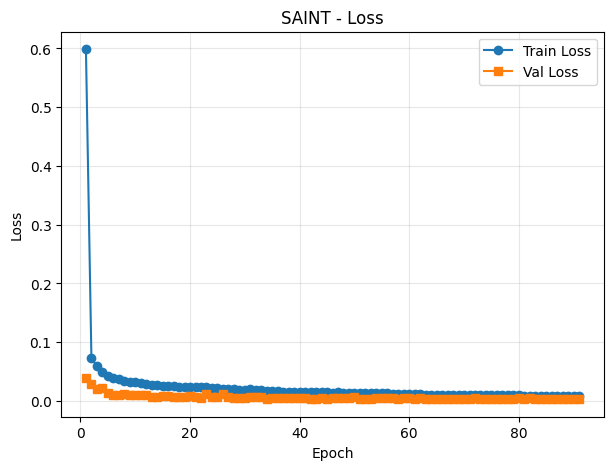

In [60]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SAINT - Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

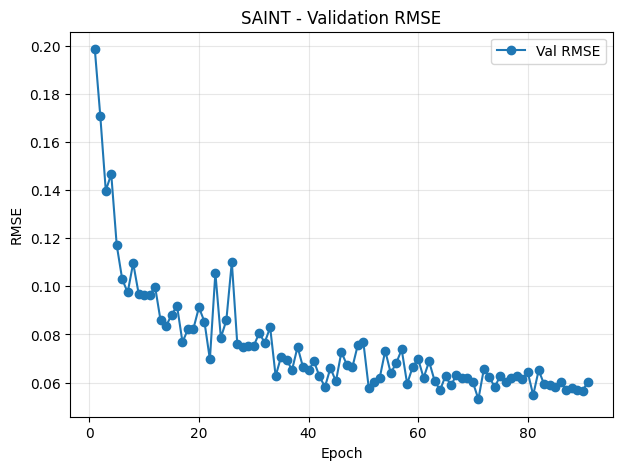

In [61]:
plt.figure(figsize=(7,5))
plt.plot(epochs, history["val_rmse"], marker="o", label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("SAINT - Validation RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

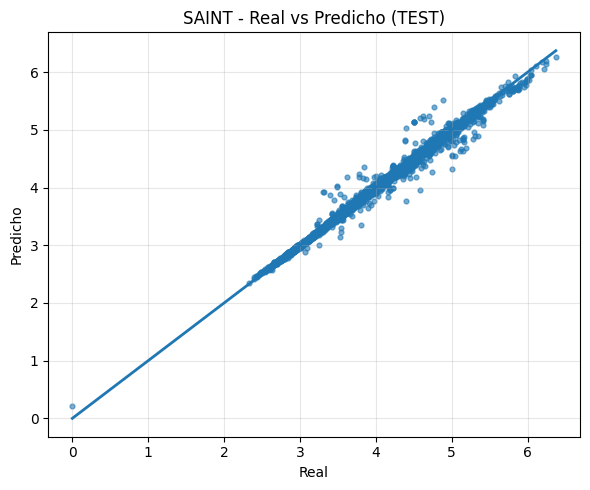

In [62]:
mn = min(y_true_test.min(), y_pred_test.min())
mx = max(y_true_test.max(), y_pred_test.max())

plt.figure(figsize=(6,5))
plt.scatter(y_true_test, y_pred_test, s=12, alpha=0.6)
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.title("SAINT - Real vs Predicho (TEST)")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()